# Introduction to PK/PD Modeling

## Learning objectives

By the end of this notebook, students should be able to:

- distinguish PK from PD
- explain the meaning of clearance, volume, and absorption rate
- understand why mechanistic PK models are preferable to generic descriptive fits
- fit a simple oral PK model for one subject
- understand the basic idea of a population model
- connect concentration to effect using a simple Emax model


---

## PK versus PD

PK and PD are branches on the pharmacometrics tree.

<img src="images/pmx-tree.png" width="800" height="700">

**Pharmacokinetics (PK)** asks what the body does to the drug.

**Pharmacodynamics (PD)** asks what the drug does to the body.

PK gives us concentration over time. PD maps concentration to effect.



<img src="images/pkpd-diagram.png" width="500" height="500">
https://www.linkedin.com/posts/kroynasdigital_what-is-pkpd-pkpd-stands-for-pharmacokinetics-activity-7262449141551628290-AnQ9/

<img src="images/pkpd-plots-concept.png" width="600" height="500">
https://aneskey.com/2-pharmacokinetic-and-pharmacodynamic-modelling-in-anaesthesia/

---

## Why do we do PK/PD modeling?

A central goal in pharmacology is to understand how a dose given to a patient leads to a biological effect.

PK/PD modeling helps us connect that full chain:

**Dose → concentration → effect**

This is useful because the measured data alone do not fully answer the questions we care about. For example:

- Why did two patients respond differently to the same dose?
- What would happen if the dose were increased or decreased?
- What would happen if the drug were given more often?
- How can we balance efficacy and toxicity?

---

## PK Modeling

### How it started

<img src="images/torsten-model.png" width="500" height="500">

### One-compartment IV bolus PK model

<img src="images/1cpt-iv.png" width="200" height="200">

Model equation:

$$\frac{dC}{dt} = -k_e C$$

with analytic solution

$$C(t) = C_0 e^{-k_e t}$$

or

$$\log C(t) = \log C_0 - k_e t$$

This gives exponential decay.

A more interpretable way to think about elimination is:

$$k_e = \frac{CL}{V}$$

where **CL** is clearance and **V** is apparent volume of distribution.

<img src="images/1cpt-bolus-lin-log.png" width="600" height="400">

### Two-compartment IV bolus PK model

Based on the drug properties, it might show a biphasic distribution (initial fast then slower)

$$
\frac{dA_1}{dt} = -(k_{10} + k_{12}) A_1 + k_{21} A_2
$$

$$
\frac{dA_2}{dt} = k_{12} A_1 - k_{21} A_2
$$


<img src="images/2cpt-bolus.png" width="600" height="400">

### One-compartment oral absorption PK model

<img src="images/1cpt-oral.png" width="200" height="200">

Model equations:

$$\frac{dD}{dt} = -k_a D$$
$$\frac{dC}{dt} = k_a D - k_e C$$

The analytic solution after a single oral dose is

$$C(t) = \frac{D k_a}{V(k_a-k_e)} \left(e^{-k_e t} - e^{-k_a t}\right)$$

This model is mechanistic because the parameters correspond to biological processes:

- $k_a$: absorption rate
- $CL$: clearance
- $V$: apparent volume
- $k_e = CL/V$: elimination rate

<img src="images/oral_model.png" width="400" height="300">

---

### Let's introduce the theophylline PK dataset

In [1]:
head(Theoph)

,Subject,Wt,Dose,Time,conc
,<ord>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,79.6,4.02,0.00,0.74
2,1,79.6,4.02,0.25,2.84
3,1,79.6,4.02,0.57,6.57
4,1,79.6,4.02,1.12,10.50
5,1,79.6,4.02,2.02,9.66
6,1,79.6,4.02,3.82,8.58


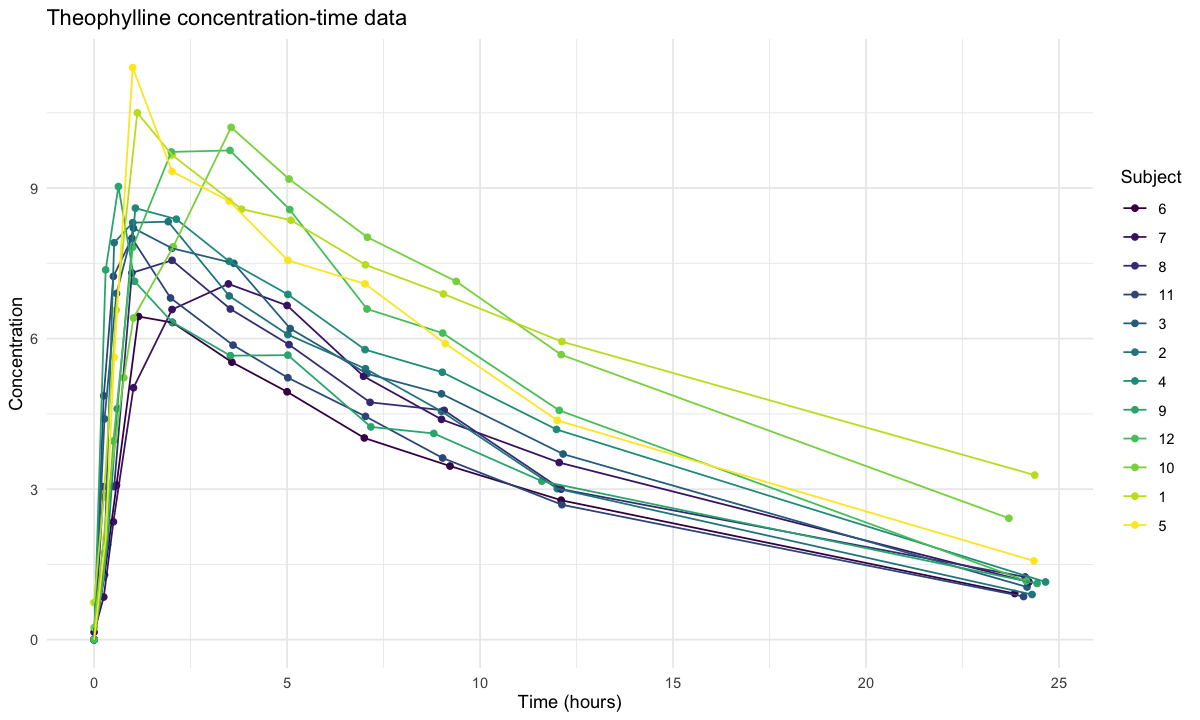

In [2]:
library(ggplot2)

options(repr.plot.width = 10, repr.plot.height = 6)

ggplot(Theoph, aes(x = Time, y = conc, group = Subject, color = Subject)) +
  geom_point() +
  geom_line() +
  labs(
    title = "Theophylline concentration-time data",
    x = "Time (hours)",
    y = "Concentration"
  ) +
  theme_minimal()


### Why the simple exponential model is not enough

Theophylline concentrations rise after dosing and then decline. That means absorption must be included, so a simple elimination-only model is not enough.


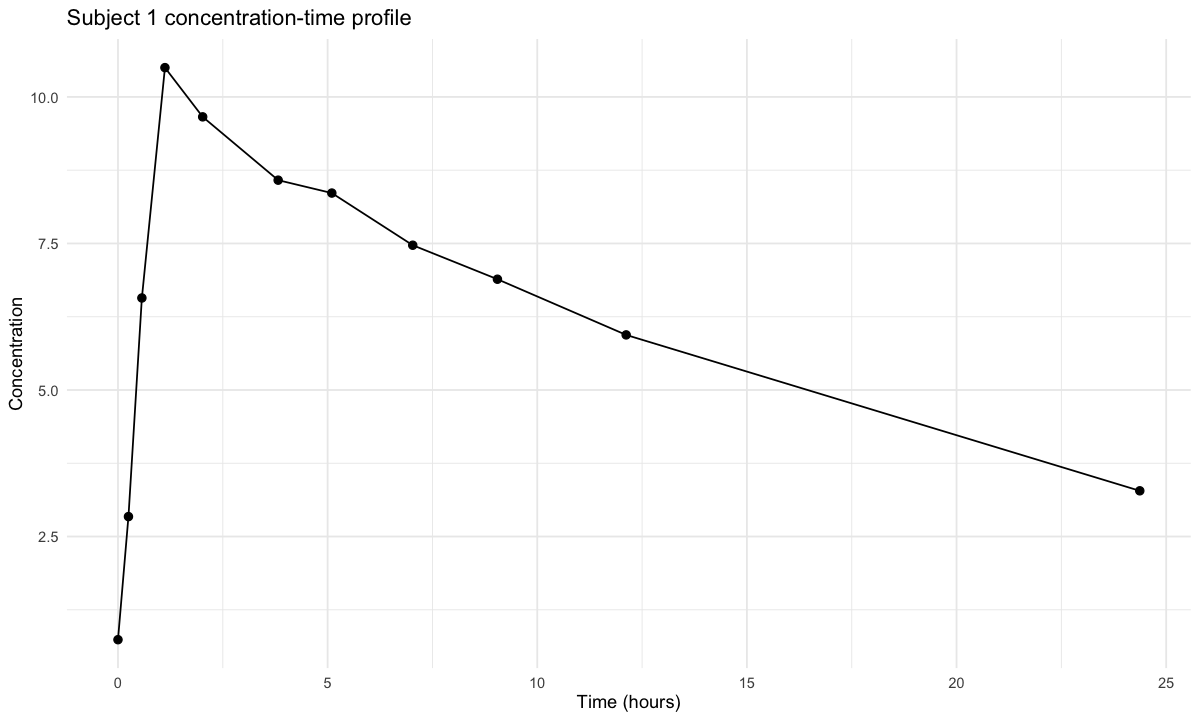

In [3]:
sub1 <- subset(Theoph, Subject == 1)

ggplot(sub1, aes(x = Time, y = conc)) +
  geom_point(size = 2) +
  geom_line() +
  labs(
    title = "Subject 1 concentration-time profile",
    x = "Time (hours)",
    y = "Concentration"
  ) +
  theme_minimal()


### Terminal-phase approximation

A semilog plot of the late phase can help build intuition about elimination, even though it is only an approximation for oral data.


`geom_smooth()` using formula = 'y ~ x'


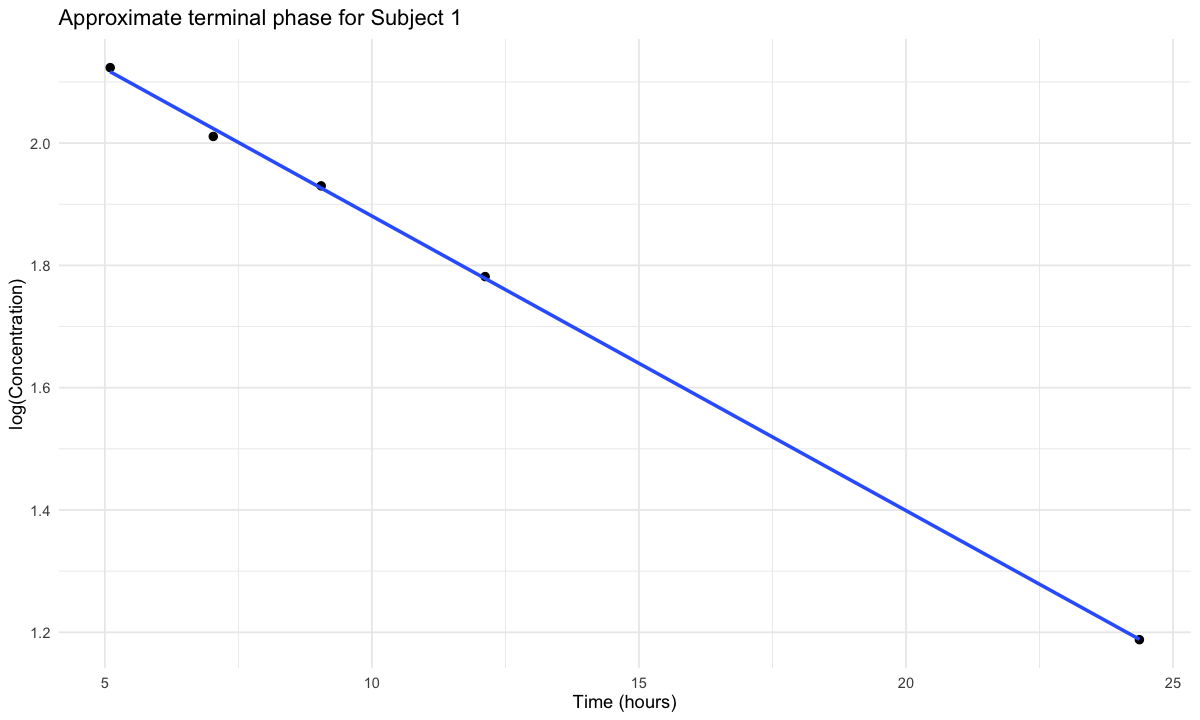

In [4]:
sub1_late <- subset(sub1, Time >= 4)

ggplot(sub1_late, aes(x = Time, y = log(conc))) +
  geom_point(size = 2) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(
    title = "Approximate terminal phase for Subject 1",
    x = "Time (hours)",
    y = "log(Concentration)"
  ) +
  theme_minimal()


In [5]:
fit_lm <- lm(log(conc) ~ Time, data = sub1_late)
summary(fit_lm)



Call:
lm(formula = log(conc) ~ Time, data = sub1_late)

Residuals:
         7          8          9         10         11 
 0.0067144 -0.0128741  0.0036126  0.0031434 -0.0005962 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.3624292  0.0077570  304.55 7.81e-08 ***
Time        -0.0481736  0.0005788  -83.23 3.82e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.008834 on 3 degrees of freedom
Multiple R-squared:  0.9996,	Adjusted R-squared:  0.9994 
F-statistic:  6928 on 1 and 3 DF,  p-value: 3.823e-06


In [6]:
ke_hat_lm <- -coef(fit_lm)[["Time"]]
t_half_lm <- log(2) / ke_hat_lm
ke_hat_lm
t_half_lm

[1] 0.04817356

[1] 14.38854

**Now, let's make prediction based on the fit parameters and overlay on the observed data to see how well the fit model characterizes the data.**

In [7]:
pred <- predict(fit_lm)

sub1_late$pred <- pred

sub1_late

,Subject,Wt,Dose,Time,conc,pred
,<ord>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
7,1,79.6,4.02,5.10,8.36,2.116744
8,1,79.6,4.02,7.03,7.47,2.023769
9,1,79.6,4.02,9.05,6.89,1.926459
10,1,79.6,4.02,12.12,5.94,1.778566
11,1,79.6,4.02,24.37,3.28,1.188440


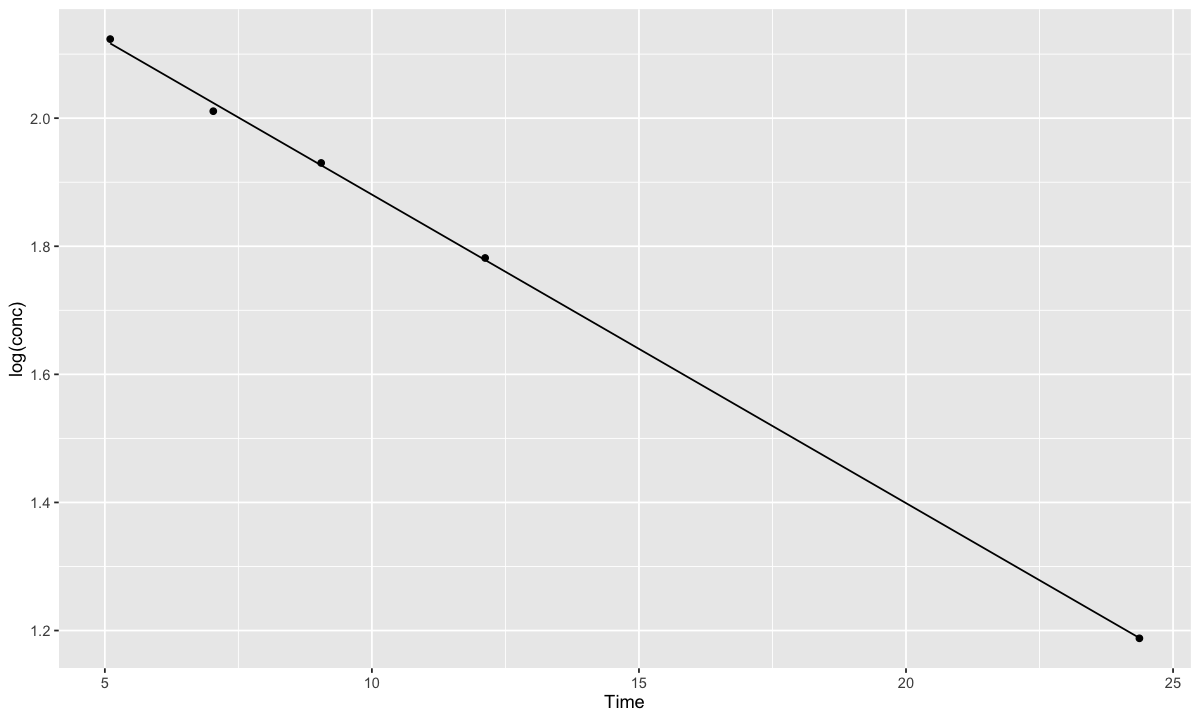

In [8]:
ggplot(data=sub1_late, aes(x=Time)) + 
    geom_point(aes(y=log(conc))) +
    geom_line(aes(y=pred))

---

### Fitting full profile with Oral PK model

We will fit a one-compartment oral absorption model to estimate the PK parameters: $k_a$, $CL$, and $V$.


Start be defining an R function that calculates theophylline concentration at a given time and dose.

In [14]:
one_comp_absorption <- function(Time, Dose, ka, CL, V) {
  k  <- CL / V

  (Dose * ka / (V * (ka - k))) *
    (exp(-k * Time) - exp(-ka * Time))
}


Now fit.

In [15]:

fit_nls_oral <- nls(
  conc ~ one_comp_absorption(Time, Dose, ka, CL, V),
  data = sub1,
  start = c(ka = 1, CL = 0.04, V = 0.5),
)

summary(fit_nls_oral)



Formula: conc ~ one_comp_absorption(Time, Dose, ka, CL, V)

Parameters:
   Estimate Std. Error t value Pr(>|t|)    
ka 1.777411   0.307164   5.787 0.000411 ***
CL 0.019923   0.002536   7.857 4.97e-05 ***
V  0.369264   0.022238  16.605 1.75e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.732 on 8 degrees of freedom

Number of iterations to convergence: 11 
Achieved convergence tolerance: 4.24e-06


In [16]:
pred <- predict(fit_nls_oral)

sub1$pred <- pred

sub1

,Subject,Wt,Dose,Time,conc,pred
,<ord>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,79.6,4.02,0.00,0.74,0.000000
2,1,79.6,4.02,0.25,2.84,3.877501
3,1,79.6,4.02,0.57,6.57,6.810848
4,1,79.6,4.02,1.12,10.50,9.035315
5,1,79.6,4.02,2.02,9.66,9.758266
6,1,79.6,4.02,3.82,8.58,9.123566
7,1,79.6,4.02,5.10,8.36,8.525233
8,1,79.6,4.02,7.03,7.47,7.683267
9,1,79.6,4.02,9.05,6.89,6.889936


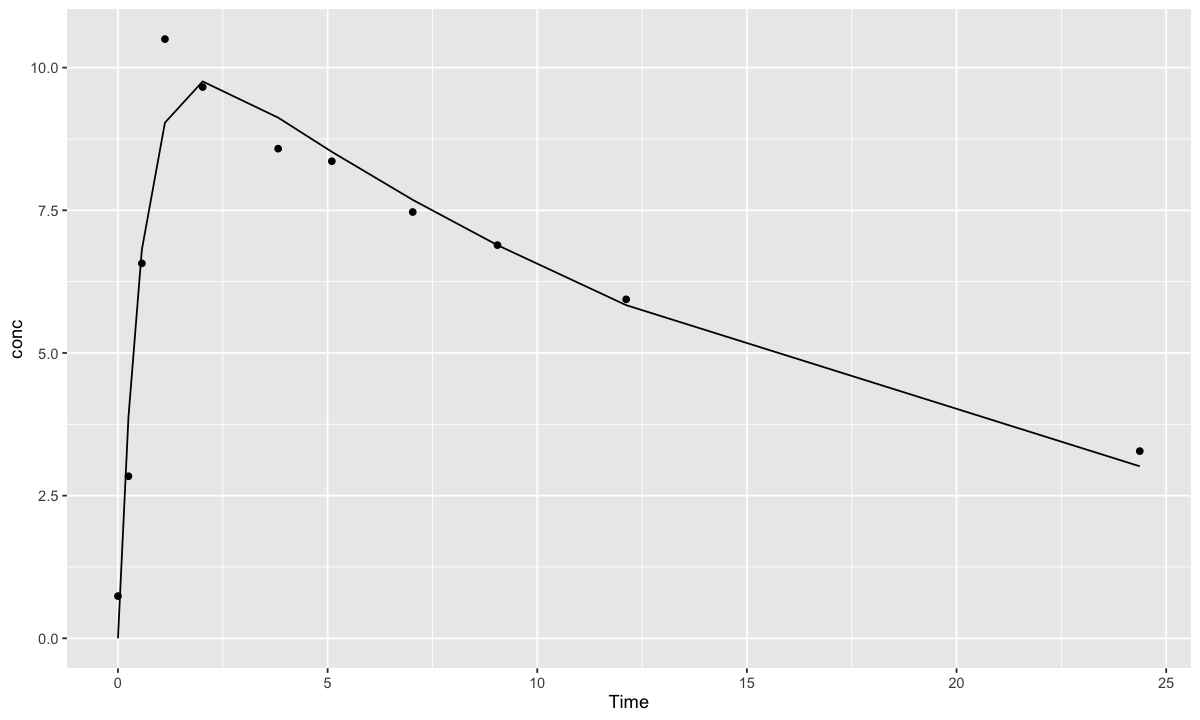

In [17]:
ggplot(data=sub1, aes(x=Time)) + 
    geom_point(aes(y=conc)) +
    geom_line(aes(y=pred))

---

### Population models

In biomedical data, individuals differ. Mixed-effects models allow us to represent both the average behavior in the population and variability between people.

For this first lecture, the idea is more important than the software details.


<img src="images/nlme.png" width="600" height="400">
https://doi.org/10.6084/m9.figshare.13578251

$$
\text{Observation} = \text{Model prediction} + \text{error}
$$

$$
y_{ij} = f(t_{ij}, \theta_i) + \varepsilon_{ij}
$$

$$
\text{Individual parameter} = \text{Population value} + \text{Individual difference}
$$

$$
\theta_i = \theta_{\mathrm{pop}} + \eta_i
$$

In [20]:
library(nlme)

fit_nlme_oral <- nlme(
  conc ~ one_comp_absorption(Time, Dose, ka, CL, V),
  data = Theoph,
  fixed  = ka + CL + V ~ 1,
  random = pdDiag(CL + V ~ 1),
  groups = ~ Subject,
  start  = c(ka = 1, CL = 0.04, V = 0.5)
)



summary(fit_nlme_oral)

Nonlinear mixed-effects model fit by maximum likelihood
  Model: conc ~ one_comp_absorption(Time, Dose, ka, CL, V) 
  Data: Theoph 
       AIC      BIC    logLik
  433.6957 450.9925 -210.8479

Random effects:
 Formula: list(CL ~ 1, V ~ 1)
 Level: Subject
 Structure: Diagonal
                 CL          V Residual
StdDev: 0.009849456 0.09264503 1.018636

Fixed effects:  ka + CL + V ~ 1 
       Value  Std.Error  DF  t-value p-value
ka 1.5156699 0.12327159 118 12.29537       0
CL 0.0398392 0.00352243 118 11.31015       0
V  0.4735819 0.03151549 118 15.02696       0
 Correlation: 
   ka     CL    
CL -0.250       
V   0.372 -0.165

Standardized Within-Group Residuals:
        Min          Q1         Med          Q3         Max 
-2.18771095 -0.48654589 -0.02378955  0.29787614  3.55861310 

Number of Observations: 132
Number of Groups: 12 

In [24]:
pred_ind <- predict(fit_nlme_oral)
pred_pop <- predict(fit_nlme_oral, level = 0)

theoph_data <- Theoph
theoph_data$pred_ind <- pred_ind
theoph_data$pred_pop <- pred_pop

head(theoph_data)


,Subject,Wt,Dose,Time,conc,pred_ind,pred_pop
,<ord>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,79.6,4.02,0.00,0.74,0.000000,0.000000
2,1,79.6,4.02,0.25,2.84,3.539779,2.647544
3,1,79.6,4.02,0.57,6.57,6.413978,4.778374
4,1,79.6,4.02,1.12,10.50,8.838957,6.533355
5,1,79.6,4.02,2.02,9.66,9.838452,7.162124
6,1,79.6,4.02,3.82,8.58,9.233459,6.489836


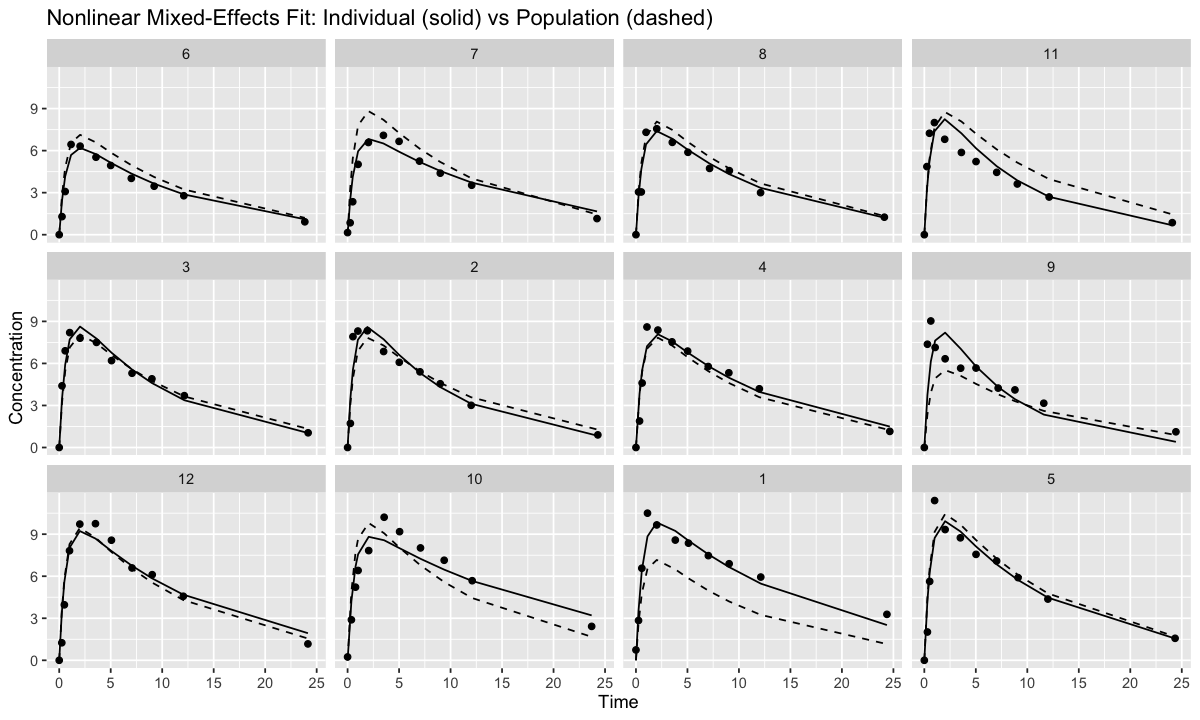

In [25]:
ggplot(theoph_data, aes(Time, conc)) +
  geom_point() +
  geom_line(aes(y = pred_ind, group = Subject)) +
  geom_line(aes(y = pred_pop, group = Subject), linetype = 2) +
  facet_wrap(~ Subject) +
  labs(
    title = "Nonlinear Mixed-Effects Fit: Individual (solid) vs Population (dashed)",
    y = "Concentration"
  )

---

## PD Modeling 

### Emax model

To keep the PD section simple, we create synthetic effect data directly from concentration using an Emax model:

$$E(C) = \frac{E_{max} C}{EC_{50} + C}$$

This shows a direct saturable concentration-effect relationship.


In [35]:
sub1

,Subject,Wt,Dose,Time,conc,dose,conc_sim
,<ord>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,79.6,4.02,0.00,0.74,4.02,0.000000
2,1,79.6,4.02,0.25,2.84,4.02,2.062092
3,1,79.6,4.02,0.57,6.57,4.02,3.883574
4,1,79.6,4.02,1.12,10.50,4.02,5.629405
5,1,79.6,4.02,2.02,9.66,4.02,6.565936
6,1,79.6,4.02,3.82,8.58,4.02,6.257997
7,1,79.6,4.02,5.10,8.36,4.02,5.709380
8,1,79.6,4.02,7.03,7.47,4.02,4.906894
9,1,79.6,4.02,9.05,6.89,4.02,4.176119


,Subject,Wt,Dose,Time,conc,effect
,<ord>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
12,2,72.4,4.4,0.00,0.00,1.00000
13,2,72.4,4.4,0.27,1.72,47.23656
14,2,72.4,4.4,0.52,7.91,80.81837
15,2,72.4,4.4,1.00,8.31,81.60136
16,2,72.4,4.4,1.92,8.33,81.63892
17,2,72.4,4.4,3.50,6.85,78.40113
18,2,72.4,4.4,5.02,6.08,76.24752
19,2,72.4,4.4,7.03,5.40,73.97297
20,2,72.4,4.4,9.00,4.55,70.46565


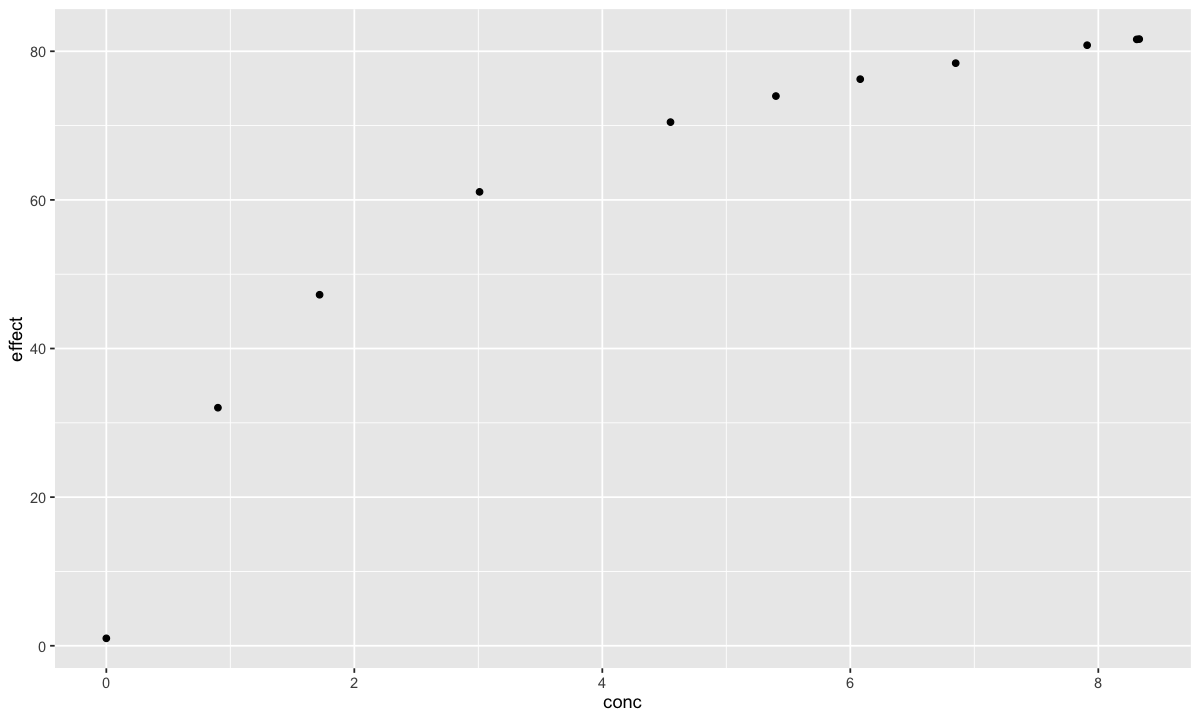

In [52]:
library(dplyr)
library(ggplot2)

sub2 <- subset(Theoph, Subject == 2)

Emax_true <- 100
EC50_true <- 2

sub2$effect <- Emax_true * sub2$conc / (EC50_true + sub2$conc)

sub2

ggplot(data=sub2, aes(x=conc, y=effect)) + geom_point()


In [55]:
fit_emax <- nls(
  effect ~ Emax * conc / (EC50 + conc),
  data = sub2,
  start = list(Emax = 90, EC50 = 5)
)

summary(fit_emax)


Formula: effect ~ Emax * conc/(EC50 + conc)

Parameters:
      Estimate Std. Error t value Pr(>|t|)    
Emax 100.59697    0.42064  239.15  < 2e-16 ***
EC50   1.94000    0.02893   67.07 1.84e-13 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.3406 on 9 degrees of freedom

Number of iterations to convergence: 5 
Achieved convergence tolerance: 8.906e-07


In [56]:
pred <- predict(fit_emax)

sub2$pred <- pred

sub2

,Subject,Wt,Dose,Time,conc,effect,pred
,<ord>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
12,2,72.4,4.4,0.00,0.00,1.00000,0.00000
13,2,72.4,4.4,0.27,1.72,47.23656,47.27502
14,2,72.4,4.4,0.52,7.91,80.81837,80.78393
15,2,72.4,4.4,1.00,8.31,81.60136,81.55712
16,2,72.4,4.4,1.92,8.33,81.63892,81.59420
17,2,72.4,4.4,3.50,6.85,78.40113,78.39464
18,2,72.4,4.4,5.02,6.08,76.24752,76.26300
19,2,72.4,4.4,7.03,5.40,73.97297,74.00863
20,2,72.4,4.4,9.00,4.55,70.46565,70.52633


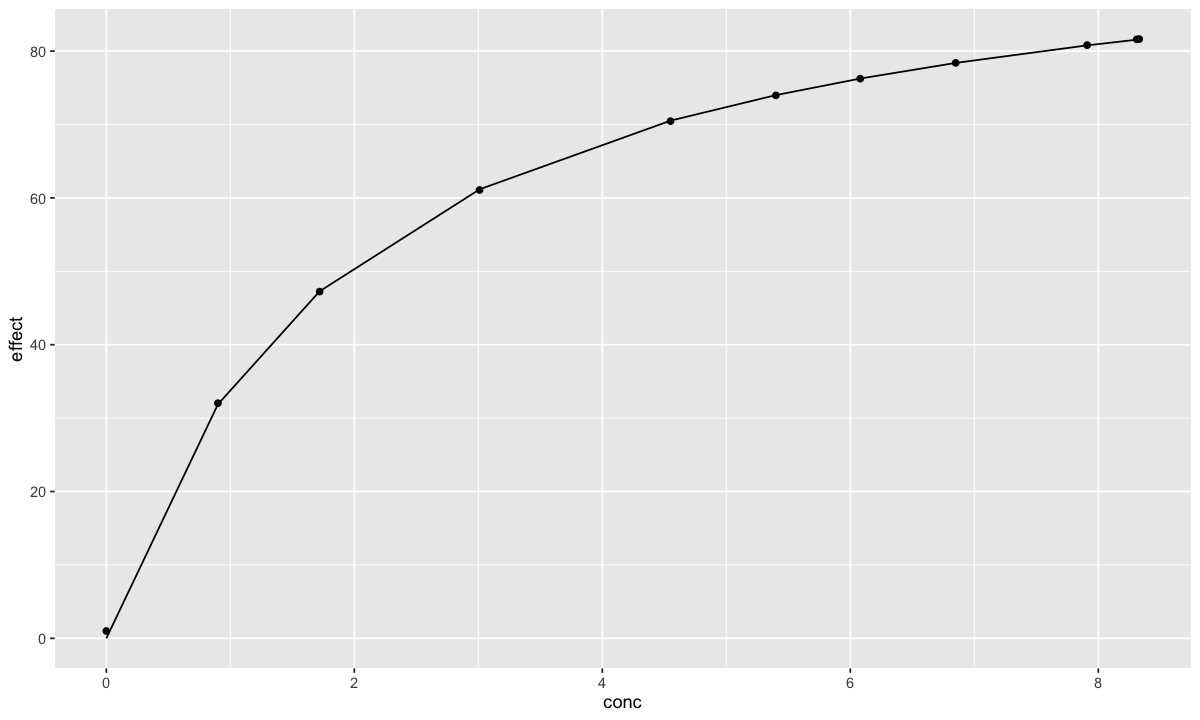

In [58]:
ggplot(data=sub2, aes(x=conc, y=effect)) +
       geom_point() +
       geom_line(aes(y=pred))

---

## ODE Simulators

In most cases, we don't have the analytic solution for the ODEs so we need to use numeric ODE simulators. Examples in R:

- mrgsolve [link](https://mrgsolve.org/)
- rxode2 [link](https://nlmixr2.github.io/rxode2/)

### Example in mrgsolve

Steps:

1. Build the model in mrgsolve (one-compartment IV bolus PK model)

In [40]:
library(mrgsolve)

code <- '
$PARAM ka = 1, CL = 1, V = 10

$CMT DEPOT CENT

$ODE
double ke = CL / V;
dxdt_DEPOT = -ka * DEPOT;
dxdt_CENT = ka * DEPOT - ke * CENT;

$TABLE
capture CP = CENT / V;
'

mod <- mcode("one_comp_iv", code)

mod

Building one_comp_iv ... 
done.





-------------  source: one_comp_iv.cpp  -------------

  project: /private/var/fol.../T/RtmpwmNVzb
  shared object: one_comp_iv-so-11d3f2023ec4e 

  time:          start: 0 end: 24 delta: 1
                 add: <none>
  compartments:  DEPOT CENT [2]
  parameters:    ka CL V [3]
  captures:      CP [1]
  omega:         0x0 
  sigma:         0x0 

  solver:        rtol: 1e-08 atol: 1e-08 itol: 1 (scalar)
------------------------------------------------------

2. Use the built model object to simulate a single 100 IV bolus dose 

In [41]:
out <- mod %>%
  ev(amt = 100, cmt = "DEPOT") %>%
  mrgsim() %>%
  as_tibble()

head(out)

ID,time,DEPOT,CENT,CP
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0,0.000000,0.00000,0.000000
1,0,100.000000,0.00000,0.000000
1,1,36.787944,59.66200,5.966200
1,2,13.533528,75.93283,7.593283
1,3,4.978707,76.78124,7.678124
1,4,1.831564,72.44493,7.244493


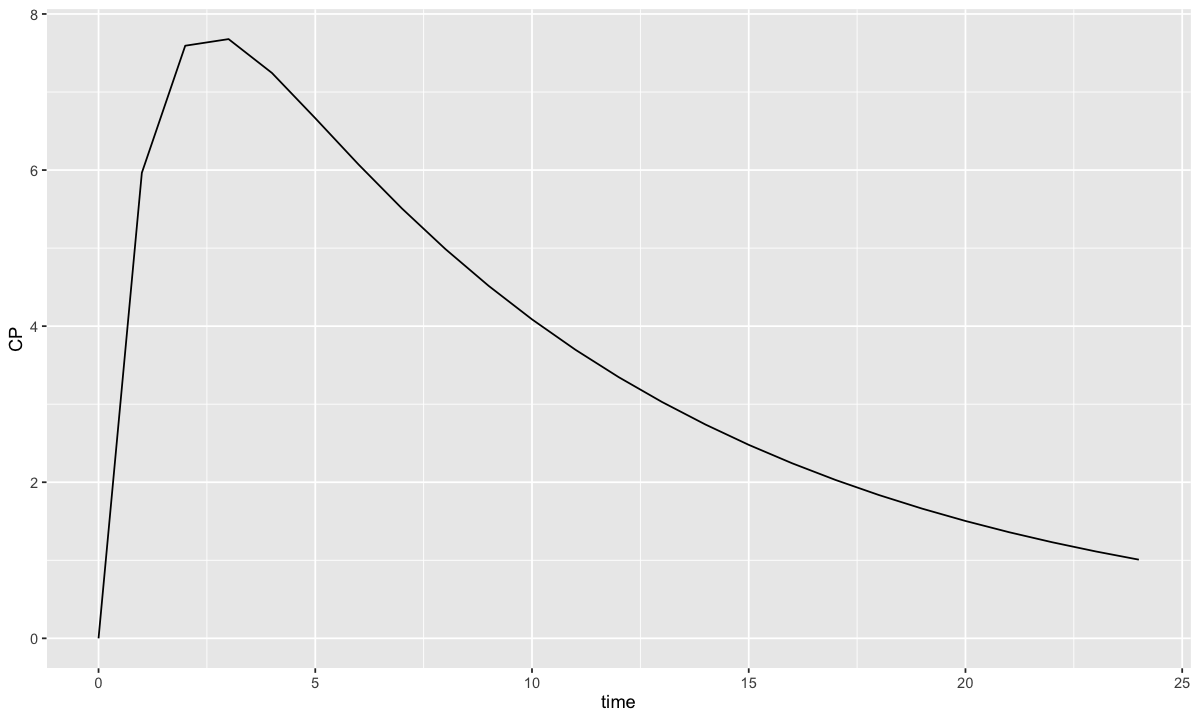

In [42]:
ggplot(data=out, aes(x=time, y=CP)) + geom_line()